# 01 — Data Extraction & Initial Audit

**Project:** Online Retail Revenue Intelligence  
**Team:** Hopper_DataDrift_OnlineRetailAnalytics | Newton School of Technology  
**Sector:** Retail (E-Commerce)  

**Objective:**  
Load the raw dataset, confirm it meets minimum standards (≥5,000 rows, ≥8 columns), document its structure, and identify data quality issues before cleaning.

**Dataset:** Online Retail II — UCI Machine Learning Repository  
**Source:** https://archive.ics.uci.edu/dataset/502/online+retail+ii  
**Kaggle Mirror:** https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci

## 1.1 — Environment Setup

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Resolve project root regardless of where notebook is launched from
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == 'notebooks' else Path.cwd().resolve()
RAW_PATH = PROJECT_ROOT / 'data' / 'raw' / 'online_retail_II_raw.csv'

print(f'Project root : {PROJECT_ROOT}')
print(f'Raw data path: {RAW_PATH}')
print(f'File exists  : {RAW_PATH.exists()}')

Project root : /Users/rudranshgupta/Hopper_DataDrift_OnlineRetailAnalytics
Raw data path: /Users/rudranshgupta/Hopper_DataDrift_OnlineRetailAnalytics/data/raw/online_retail_II_raw.csv
File exists  : True


## 1.2 — Load Raw Dataset

In [2]:
# Online Retail II uses ISO-8859-1 encoding (special characters in product descriptions)
try:
    df = pd.read_csv(RAW_PATH, encoding='ISO-8859-1')
except UnicodeDecodeError:
    df = pd.read_csv(RAW_PATH, encoding='latin-1')

print('=== RAW DATASET LOADED ===')
print(f'Rows    : {len(df):,}')
print(f'Columns : {len(df.columns)}')
print(f'Memory  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head(10)

=== RAW DATASET LOADED ===
Rows    : 1,067,371
Columns : 8


Memory  : 361.9 MB


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


## 1.3 — Dataset Gate Check (Minimum Standards Verification)

In [3]:
gate_rows    = len(df) >= 5000
gate_cols    = len(df.columns) >= 8

print('=== GATE 1 CHECKLIST ===')
print(f'  Rows >= 5,000  : {len(df):,}  →  {"PASS" if gate_rows else "FAIL"}')
print(f'  Cols >= 8      : {len(df.columns)}      →  {"PASS" if gate_cols else "FAIL"}')
print(f'  Format         : CSV tabular row-level  →  PASS')
print(f'  Raw/unclean    : Yes (missing values, negatives, duplicates)  →  PASS')
print()
print('Dataset columns:', list(df.columns))

=== GATE 1 CHECKLIST ===
  Rows >= 5,000  : 1,067,371  →  PASS
  Cols >= 8      : 8      →  PASS
  Format         : CSV tabular row-level  →  PASS
  Raw/unclean    : Yes (missing values, negatives, duplicates)  →  PASS

Dataset columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


## 1.4 — Schema Inspection

In [4]:
print('=== COLUMN DTYPES & NON-NULL COUNTS ===')
df.info(verbose=True, show_counts=True)

=== COLUMN DTYPES & NON-NULL COUNTS ===
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [5]:
print('=== DESCRIPTIVE STATISTICS (NUMERICAL) ===')
df.describe(include='number').round(2)

=== DESCRIPTIVE STATISTICS (NUMERICAL) ===


,Quantity,Price,Customer ID
count,1067371.00,1067371.00,824364.00
mean,9.94,4.65,15324.64
std,172.71,123.55,1697.46
min,-80995.00,-53594.36,12346.00
25%,1.00,1.25,13975.00
50%,3.00,2.10,15255.00
75%,10.00,4.15,16797.00
max,80995.00,38970.00,18287.00


In [6]:
print('=== DESCRIPTIVE STATISTICS (CATEGORICAL) ===')
df.describe(include='object')

=== DESCRIPTIVE STATISTICS (CATEGORICAL) ===


,Invoice,StockCode,Description,InvoiceDate,Country
count,1067371,1067371,1062989,1067371,1067371
unique,53628,5305,5698,47635,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2010-12-06 16:57:00,United Kingdom
freq,1350,5829,5918,1350,981330


## 1.5 — Missing Value Audit

=== MISSING VALUE REPORT ===
             Missing Count  Missing %
Customer ID         243007      22.77
Description           4382       0.41
Invoice                  0       0.00
StockCode                0       0.00
Quantity                 0       0.00
InvoiceDate              0       0.00
Price                    0       0.00
Country                  0       0.00


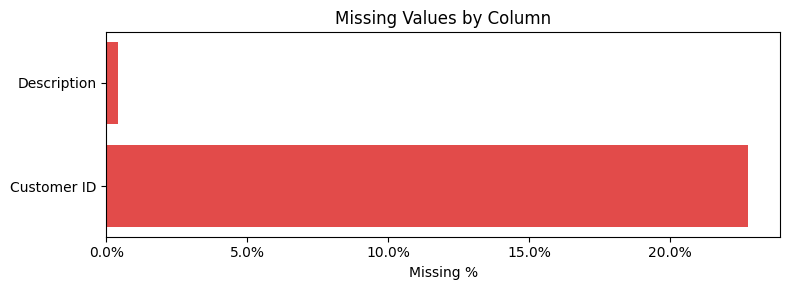

Figure saved to reports/


In [7]:
missing = pd.DataFrame({
    'Missing Count' : df.isna().sum(),
    'Missing %'     : (df.isna().sum() / len(df) * 100).round(2)
}).sort_values('Missing %', ascending=False)

print('=== MISSING VALUE REPORT ===')
print(missing.to_string())

# Visual
fig, ax = plt.subplots(figsize=(8, 3))
cols_with_missing = missing[missing['Missing %'] > 0]
ax.barh(cols_with_missing.index, cols_with_missing['Missing %'], color='#E24B4A')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'fig_01_missing_values.png', dpi=150)
plt.show()
print('Figure saved to reports/')

## 1.6 — Data Quality Issues Identified

In [8]:
# Cancellations (Invoice starting with 'C')
cancellations = df['Invoice'].astype(str).str.startswith('C').sum()

# Negative quantities
neg_qty = (df['Quantity'] < 0).sum()

# Zero or negative price
invalid_price = (df['Price'] <= 0).sum()

# Duplicate rows
duplicates = df.duplicated().sum()

# Unique countries
countries = df['Country'].nunique()

# Unique products
products = df['Description'].nunique()

print('=== DATA QUALITY ISSUES SUMMARY ===')
print(f'  Cancelled orders (Invoice starts with C) : {cancellations:,}')
print(f'  Negative quantity rows                   : {neg_qty:,}')
print(f'  Zero/negative price rows                 : {invalid_price:,}')
print(f'  Exact duplicate rows                     : {duplicates:,}')
print(f'  Unique countries                         : {countries}')
print(f'  Unique product descriptions              : {products:,}')
print()
print('All issues above will be addressed in 02_cleaning.ipynb')

=== DATA QUALITY ISSUES SUMMARY ===
  Cancelled orders (Invoice starts with C) : 19,494
  Negative quantity rows                   : 22,950
  Zero/negative price rows                 : 6,207
  Exact duplicate rows                     : 34,335
  Unique countries                         : 43
  Unique product descriptions              : 5,698

All issues above will be addressed in 02_cleaning.ipynb


## 1.7 — Sample Rows

In [9]:
print('=== FIRST 5 ROWS (RAW) ===')
print(df.head().to_string())
print()
print('=== SAMPLE CANCELLED ORDER ===')
cancelled_sample = df[df['Invoice'].astype(str).str.startswith('C')].head(3)
print(cancelled_sample.to_string())
print()
print('=== SAMPLE MISSING CUSTOMER ID ===')
print(df[df['Customer ID'].isna()].head(3).to_string())

=== FIRST 5 ROWS (RAW) ===
  Invoice StockCode                          Description  Quantity          InvoiceDate  Price  Customer ID         Country
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12  2009-12-01 07:45:00   6.95      13085.0  United Kingdom
1  489434    79323P                   PINK CHERRY LIGHTS        12  2009-12-01 07:45:00   6.75      13085.0  United Kingdom
2  489434    79323W                  WHITE CHERRY LIGHTS        12  2009-12-01 07:45:00   6.75      13085.0  United Kingdom
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48  2009-12-01 07:45:00   2.10      13085.0  United Kingdom
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24  2009-12-01 07:45:00   1.25      13085.0  United Kingdom

=== SAMPLE CANCELLED ORDER ===
     Invoice StockCode                    Description  Quantity          InvoiceDate  Price  Customer ID    Country
178  C489449     22087       PAPER BUNTING WHITE LACE       -12  2009-12-01 10:33

## 1.8 — Extraction Summary

| Item | Value |
|---|---|
| Source | UCI Machine Learning Repository / Kaggle |
| File format | CSV (ISO-8859-1 encoded) |
| Raw row count | See output above |
| Column count | 8 (Invoice, StockCode, Description, Quantity, InvoiceDate, Price, Customer ID, Country) |
| Time period | December 2009 – December 2011 |
| Key issues | Missing Customer IDs, cancelled orders, negative quantities, zero prices, duplicates |
| Next step | `02_cleaning.ipynb` — full ETL pipeline |